In [ ]:
# Import libraries
import kagglehub
import shutil
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.stats as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import itertools
import pingouin as pg

# Load data

In [ ]:
# load data from Kaggle
tmp = kagglehub.dataset_download('jawadaahmed/mobile-price-dataset')
target = os.getcwd()
shutil.copytree(tmp, target, dirs_exist_ok=True)

'/Users/daniil/Documents/Other Projects/data-analysis-projects/04_Mobile_Price'

In [215]:
df = pd.read_csv('mobile_price_dataset.csv')
print(f'Dimensions of the data: {df.shape}')
df.head()

Dimensions of the data: (15, 10)


,Brand,Model,Price_USD,RAM_GB,Storage_GB,Battery_mAh,Screen_Size_Inch,Camera_MP,OS,Release_Year
0,Samsung,Galaxy S21,799,8,128,4000,6.20,64,Android,2021
1,Apple,iPhone 13,999,4,128,3240,6.10,12,iOS,2021
2,Xiaomi,Redmi Note 11,199,6,128,5000,6.43,50,Android,2022
3,Realme,Realme 9 Pro,299,8,128,5000,6.60,64,Android,2022
4,OnePlus,OnePlus 9,729,8,128,4500,6.55,48,Android,2021


# EDA

In [216]:
# Numeric data stats
numeric_df = df.select_dtypes(include='number')
numeric_df.describe()

,Price_USD,RAM_GB,Storage_GB,Battery_mAh,Screen_Size_Inch,Camera_MP,Release_Year
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,441.000000,6.266667,123.733333,4464.333333,6.472667,49.400000,2021.066667
std,277.004384,1.667619,45.038819,706.391400,0.204955,24.523458,0.593617
min,199.000000,4.000000,64.000000,2815.000000,6.100000,12.000000,2020.000000
25%,234.000000,5.000000,128.000000,4100.000000,6.415000,48.000000,2021.000000
50%,299.000000,6.000000,128.000000,4500.000000,6.510000,48.000000,2021.000000
75%,614.000000,8.000000,128.000000,5000.000000,6.600000,64.000000,2021.000000
max,999.000000,8.000000,256.000000,5160.000000,6.800000,108.000000,2022.000000


In [217]:
# Check for NAs
print(df.isna().sum())

Brand               0
Model               0
Price_USD           0
RAM_GB              0
Storage_GB          0
Battery_mAh         0
Screen_Size_Inch    0
Camera_MP           0
OS                  0
Release_Year        0
dtype: int64


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0.5, 0, 'Price_USD'),
  Text(1.5, 0, 'RAM_GB'),
  Text(2.5, 0, 'Storage_GB'),
  Text(3.5, 0, 'Battery_mAh'),
  Text(4.5, 0, 'Screen_Size_Inch'),
  Text(5.5, 0, 'Camera_MP'),
  Text(6.5, 0, 'Release_Year')])

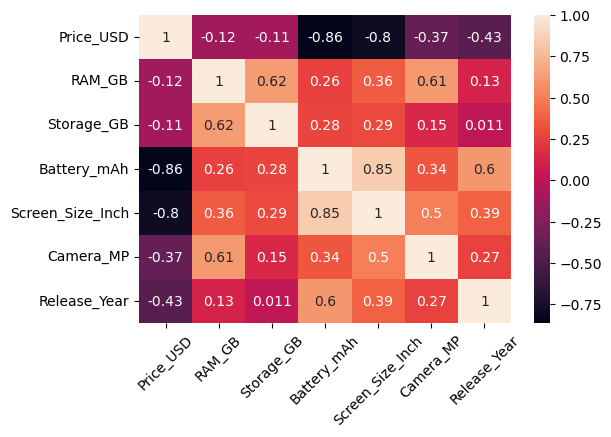

In [218]:
# Correlation matrix
cor_mat = numeric_df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(cor_mat, annot=True)
plt.xticks(rotation=45, ha='center')

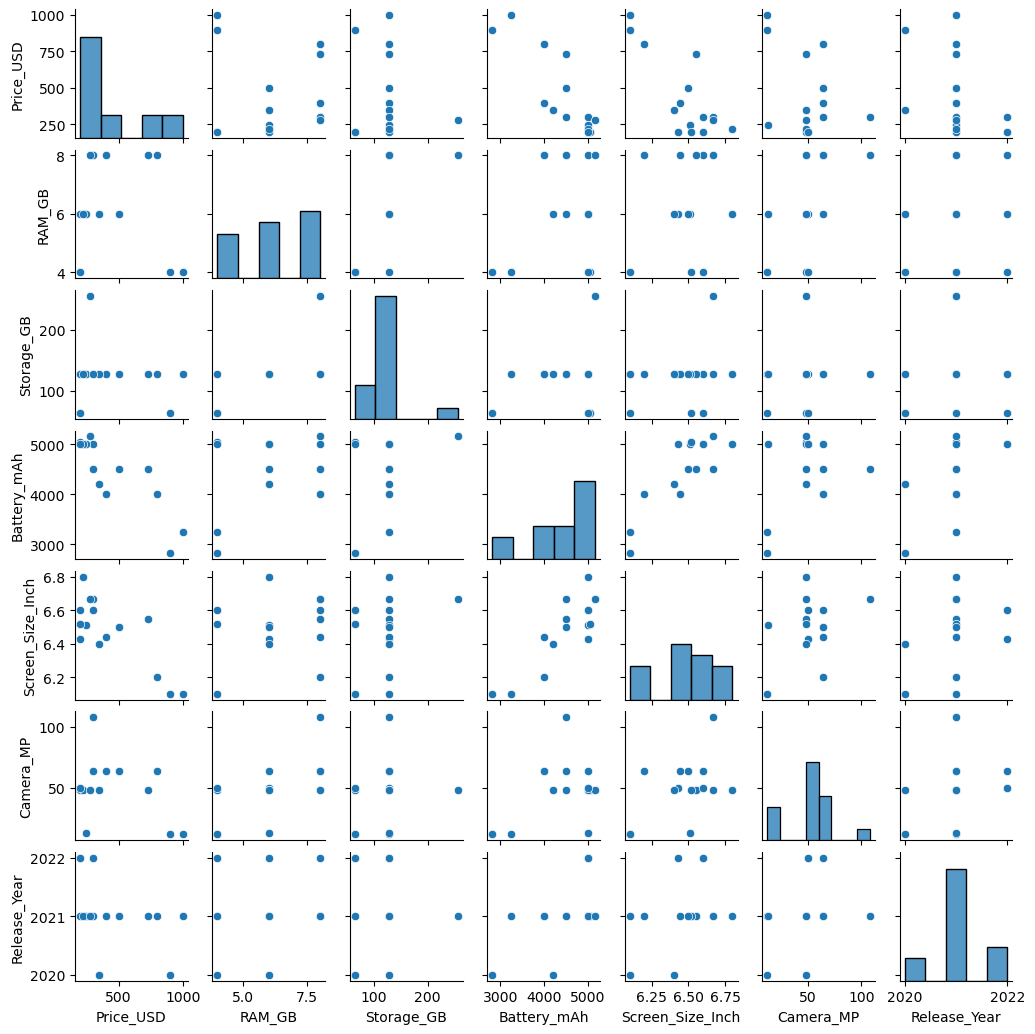

In [219]:
# pairwise scatterplots
sns.pairplot(df, height=1.5)

Some features are highly correlated (e.g., `Screen_Size_Inch` and `Battery_mAh`) - it can be an issue for linear regression.

In [ ]:
# VIF
X = numeric_df.drop(columns= 'Price_USD')
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['features'] = X.columns
vif

,VIF,features
0,49.548856,RAM_GB
1,19.038496,Storage_GB
2,158.570346,Battery_mAh
3,4592.538344,Screen_Size_Inch
4,12.619939,Camera_MP
5,3230.922480,Release_Year


VIF suggests that some variables are highly correlated. Let's run PCA for variables with the biggest VIF values to reduce the dimensionality.

## PCA

In [221]:
# Pre-process
X_pca = df[['Screen_Size_Inch','Battery_mAh','RAM_GB','Storage_GB']]
X_pca_scaled = StandardScaler().fit_transform(X_pca)

# PCA
pca_model = PCA(n_components=2)
pca_data = pca_model.fit_transform(X_pca_scaled)

# Diagnostics
print(f'Explained variance: {pca_model.explained_variance_ratio_.round(3)}.',
      f'Total: {pca_model.explained_variance_ratio_.sum():.1%}', end='\n\n')
print('Linear relationship:')
print(
    pd.DataFrame(
    pca_model.components_,
    columns=['Screen_Size_Inch','Battery_mAh','RAM_GB','Storage_GB'],
    index=['PC1','PC2']
))


Explained variance: [0.585 0.283]. Total: 86.9%

Linear relationship:
     Screen_Size_Inch  Battery_mAh    RAM_GB  Storage_GB
PC1          0.556268     0.530940  0.459161    0.444791
PC2         -0.418871    -0.484841  0.529724    0.555760


Now, just two new features explain 86.9% of variability of four original features.

In [ ]:
# New VIF
X = numeric_df.drop(columns= ['Price_USD',
                              'Screen_Size_Inch','Battery_mAh','RAM_GB','Storage_GB'])
X['PC1'] = pca_data[:,0]
X['PC2'] = pca_data[:,1]
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['features'] = X.columns
vif

,VIF,features
0,7.411251,Camera_MP
1,7.025479,Release_Year
2,1.384330,PC1
3,1.001122,PC2


New VIFs look much better, let's construct the final data frame

In [223]:
df['PC1'] = pca_data[:,0]
df['PC2'] = pca_data[:,1]

# Linear Regression

Note that since the number of observations is very small (15), we can't use all the features (otherwise the number of parameters is going to be bigger than the number of observations, especially with dummy variables). Thus, we are going to use only one categorical variable - `OS`.

In [224]:
model = smf.ols('Price_USD ~ OS + Camera_MP + Release_Year + PC1 + PC2', data = df).fit()
model.summary()

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Price_USD   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     7.148
Date:                Thu, 16 Apr 2026   Prob (F-statistic):            0.00581
Time:                        22:45:59   Log-Likelihood:                -93.100
No. Observations:                  15   AIC:                             198.2
Df Residuals:                       9   BIC:                             202.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -4.245e+04   1.67e+05     -0.253      0.806   -4.21e+05    3.36e+05
OS[T.iOS]      176.9541    240.047      0.737      0.480    -366.070     719.978
Camera_MP       -0.0336      2.240     -0.015      0.988      -5.102       5.035
Release_Year    21.2091     82.874      0.256      0.804    -166.264     208.682
PC1            -86.3853     47.796     -1.807      0.104    -194.507      21.737
PC2            138.2323     46.416      2.978      0.015      33.233     243.232
==============================================================================
Omnibus:                        6.024   Durbin-Watson:                   2.085
Prob(Omnibus):                  0.049   Jarque-Bera (JB):                3.016
Skew:                           0.969   Prob(JB):                        0.221
Kurtosis:                       4.035   Cond. No.                     8.46e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.46e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Model Selection

In [ ]:
# AIC-based selection
def stepwise_aic(data, response, predictors):

    best_aic = float('inf')
    best_model = None
    best_formula = None

    for k in range(1, len(predictors)+1):
        for combo in itertools.combinations(predictors, k):
            formula = response + ' ~ ' + ' + '.join(combo)
            model = smf.ols(formula, data=data).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
                best_formula = formula

    return best_formula, best_model

In [257]:
# Model Selection
best_formula, best_model = stepwise_aic(data = df, 
                                        response = 'Price_USD',
                                        predictors = ['OS','Camera_MP','Release_Year','PC1','PC2'])
best_model.summary()

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Price_USD   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     21.46
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           0.000109
Time:                        23:22:43   Log-Likelihood:                -93.720
No. Observations:                  15   AIC:                             193.4
Df Residuals:                      12   BIC:                             195.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    441.0000     36.112     12.212      0.000     362.320     519.680
PC1         -114.7475     23.600     -4.862      0.000    -166.168     -63.327
PC2          148.9038     33.914      4.391      0.001      75.012     222.796
==============================================================================
Omnibus:                        2.727   Durbin-Watson:                   1.889
Prob(Omnibus):                  0.256   Jarque-Bera (JB):                0.946
Skew:                           0.548   Prob(JB):                        0.623
Kurtosis:                       3.558   Cond. No.                         1.53
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Model diagnostics

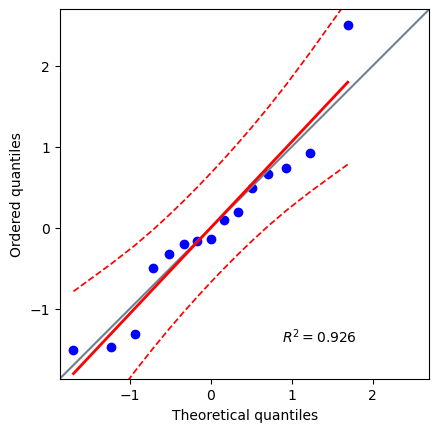

          W      pval  normal
0  0.934978  0.323392    True


In [ ]:
er = best_model.resid
fitted = best_model.fittedvalues

# Normality
pg.qqplot(er)
plt.show()
print(pg.normality(er))

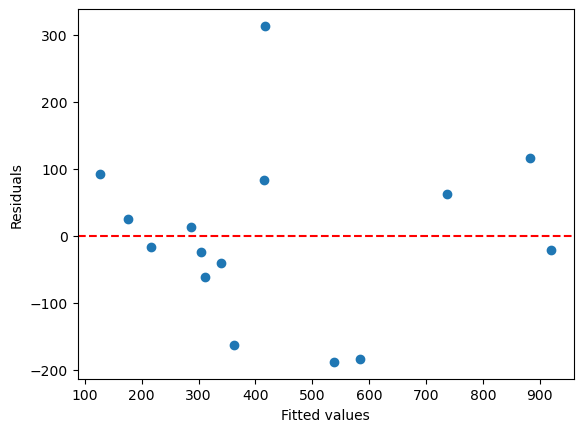

LM stat       0.805522
LM p-value    0.668472
F stat        0.340494
F p-value     0.718074
dtype: float64


In [ ]:
# Heteroscedasticity
plt.scatter(fitted, er)
plt.axhline(0, color = 'red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

print(pd.Series(
    list(sms.diagnostic.het_breuschpagan(er, best_model.model.exog)),
    index = ['LM stat', 'LM p-value', 'F stat', 'F p-value']
))

Residuals are normally distributed and no heteroscedasticity is found.

## Visualization

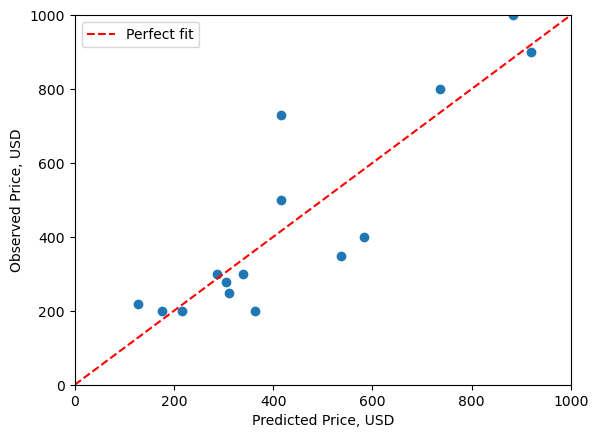

In [273]:
plt.scatter(fitted, y)
plt.axline((0,0), slope = 1, color = 'red', linestyle='--',
           label = 'Perfect fit')
plt.legend()
plt.xlabel('Predicted Price, USD')
plt.ylabel('Observed Price, USD')
plt.xlim([0, 1000])
plt.ylim([0, 1000])
plt.show()

# Summary

An OLS regression model was estimated to predict Price (USD). During exploratory data analysis, PCA was applied to reduce dimensionality and address potential multicollinearity among predictors. Due to the very small sample size (n = 15), most categorical variables were excluded to avoid overparameterization.

Model selection was performed using an exhaustive search approach (“leaps and bounds”), comparing all possible subsets of predictors based on the AIC criterion. The final model includes two principal components and demonstrates a good fit to the data (R² = 0.781, adjusted R² = 0.745).

Diagnostic checks did not reveal major violations of model assumptions, including heteroscedasticity or non-normality of residuals. Overall, the results suggest that price variation can be reasonably explained by underlying latent structure in the features captured by the principal components.